# Laboratorio 6  Reconstrucción del Laboratorio 3 con PyTorch
### Precio de viviendas: Regresión Lineal, Regresión Polinómica, y Ecuación de la Normal

**Dataset:** housing.csv - Ames Housing<br>
**Modelos originales (Laboratorio 3):** tres modelos en un solo cuadernillo, todos implementados con NumPy: Modelo 1 (regresión lineal multivariable por descenso de gradiente), Modelo 2 (regresión polinómica, agregando el cuadrado de las 6 propiedades más correlacionadas con el precio), y Modelo 3 (Ecuación de la Normal).<br>
**Objetivo de este laboratorio:** reconstruir los tres modelos con PyTorch, aplicando las dos lecciones ya aprendidas al reconstruir el Laboratorio 2: ajustar la tasa de aprendizaje por la diferencia de escala de `MSELoss`, y usar un criterio de parada por convergencia en lugar de un número de iteraciones fijo.<br>

**Nota importante sobre la Ecuación de la Normal:** no es un modelo que se entrena con gradientes ni con un optimizador es una fórmula cerrada de álgebra lineal. Por eso, en este notebook, el Modelo 3 no usa `Dataset`, `DataLoader`, ni `torch.optim`; solo usa tensores de PyTorch para el cálculo matricial, tal como se justificó al reconstruir el Laboratorio 2.<br>
**Link Repositorio:**  https://github.com/jccondoric/machine_learning/tree/master/Laboratorios/Laboratorio_6/Pytorch_Laboratorio_3<br>
**Link del Video explicacion:**
https://drive.google.com/drive/folders/1Ofw7HVEcI3YRluF0P9pasr1JluIkDGJ2?usp=sharing<br>

In [2]:
# conectando vinculando nuestro drive con la sesion de google colab (notebook)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Cargando libreria de Pytorch
import torch
import pandas as pd
import numpy as np
# para graficar
import matplotlib.pyplot as plt
torch.manual_seed(42)
np.random.seed(42)
# incrustar las graficas dentro del notebook
%matplotlib inline

## 1. Carga y limpieza del dataset

Se reutiliza exactamente la misma limpieza del Laboratorio 3 original: eliminar las columnas identificadoras (`Unnamed: 0`, `Order`, `PID`), quedarse solo con columnas numéricas, imputar con 0 las columnas donde el nulo significa "no tiene esa característica" (por ejemplo, un lote sin garaje), e imputar `Lot Frontage` con la mediana.

In [5]:
df = pd.read_csv('/content/drive/MyDrive/IA/Laboratorios/Laboratorio_6/Pytorch_Laboratorio_3/housing.csv')
data = df.drop(columns=['Unnamed: 0', 'Order', 'PID'])
data = data.select_dtypes(include='number').copy()

cols_sin_caracteristica = ['Garage Yr Blt', 'Mas Vnr Area', 'Bsmt Full Bath', 'Bsmt Half Bath',
                            'Garage Cars', 'Garage Area', 'Bsmt Unf SF', 'BsmtFin SF 1',
                            'BsmtFin SF 2', 'Total Bsmt SF']
for col in cols_sin_caracteristica:
    data[col] = data[col].fillna(0)
data['Lot Frontage'] = data['Lot Frontage'].fillna(data['Lot Frontage'].median())

print('Valores faltantes después de la imputación:', data.isnull().sum().sum())
print('Dimensiones finales:', data.shape)

Valores faltantes después de la imputación: 0
Dimensiones finales: (2930, 37)


In [6]:
y = data['SalePrice'].values.astype(float)
X = data.drop(columns=['SalePrice']).values.astype(float)
feature_names = data.drop(columns=['SalePrice']).columns.tolist()

m, n = X.shape
print(f'm = {m}  (registros)')
print(f'n = {n}  (características)')

m = 2930  (registros)
n = 36  (características)


## 2. División 80/20 y normalización

Misma división manual con `np.random.permutation` y `seed=42` del Laboratorio 3 original, con al menos 100 predicciones de prueba exigidas por el enunciado (aquí quedan 586).

In [7]:
idx = np.random.permutation(m)
test_size = int(0.2 * m)
test_idx, train_idx = idx[:test_size], idx[test_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
m_train, m_test = X_train.shape[0], X_test.shape[0]

print(f'm_train = {m_train}')
print(f'm_test  = {m_test}  (predicciones de prueba, >= 100: {m_test >= 100})')

m_train = 2344
m_test  = 586  (predicciones de prueba, >= 100: True)


In [8]:
def normalizar(X, mu=None, sigma=None):
    if mu is None:
        mu = X.mean(axis=0)
        sigma = X.std(axis=0)
        sigma[sigma == 0] = 1
    return (X - mu) / sigma, mu, sigma

X_train_norm, mu, sigma = normalizar(X_train)
X_test_norm, _, _ = normalizar(X_test, mu, sigma)

y_mu, y_sigma = y_train.mean(), y_train.std()
y_train_norm = (y_train - y_mu) / y_sigma
y_test_norm = (y_test - y_mu) / y_sigma

## 3. Función de evaluación (reutilizada en los tres modelos)

Se define una sola función `evaluar`, igual que en el Laboratorio 3, para no repetir el cálculo de métricas tres veces.

In [9]:
def evaluar(y_true, y_pred):
    mse = np.mean((y_pred - y_true) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_pred - y_true))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return mse, rmse, mae, r2

## 4. Modelo 1: Regresión Lineal Multivariable (PyTorch)

Se usa el mismo esquema de las reconstrucciones anteriores: `Dataset`/`DataLoader` de PyTorch con el conjunto de entrenamiento completo en un solo lote (para replicar el descenso de gradiente por lotes del original), `torch.nn.Linear(36, 1)`, `MSELoss`, y `SGD`.

**Tasa de aprendizaje:** el Laboratorio 3 original usó `alpha1=0.1`. Aplicando la misma corrección aprendida en el Laboratorio 2 (compensar el factor 1/2 que `MSELoss` no incluye), se usa `lr=0.05`.

**Criterio de parada:** igual que en las reconstrucciones anteriores, se detiene quando el costo deja de cambiar de forma significativa (diferencia menor a 1e-6) en lugar de forzar siempre las 3000 iteraciones del original.

In [10]:
X_train_t = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_t = torch.tensor(y_train_norm, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_norm, dtype=torch.float32)

class DatasetViviendas(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset1 = DatasetViviendas(X_train_t, y_train_t)
dataloader1 = torch.utils.data.DataLoader(dataset1, batch_size=len(dataset1), shuffle=False)

modelo1 = torch.nn.Linear(n, 1)
criterion = torch.nn.MSELoss()
optimizer1 = torch.optim.SGD(modelo1.parameters(), lr=0.05)

In [11]:
max_epocas = 3000
historial1 = []

for epoca in range(max_epocas):
    for x_lote, y_lote in dataloader1:
        optimizer1.zero_grad()
        y_pred = modelo1(x_lote)
        loss = criterion(y_pred, y_lote)
        loss.backward()
        optimizer1.step()
    historial1.append(loss.item())
    if epoca > 0 and abs(historial1[-2] - historial1[-1]) < 1e-6:
        print(f'Convergencia alcanzada en la época {epoca}')
        break

print(f'Costo inicial (dividido entre 2, comparable con el Lab3 original): {historial1[0]/2:.4f}')
print(f'Costo final   (dividido entre 2, comparable con el Lab3 original): {historial1[-1]/2:.5f}')

Convergencia alcanzada en la época 179
Costo inicial (dividido entre 2, comparable con el Lab3 original): 0.4589
Costo final   (dividido entre 2, comparable con el Lab3 original): 0.08165


### 4.1 Gráfico de costo - Modelo 1

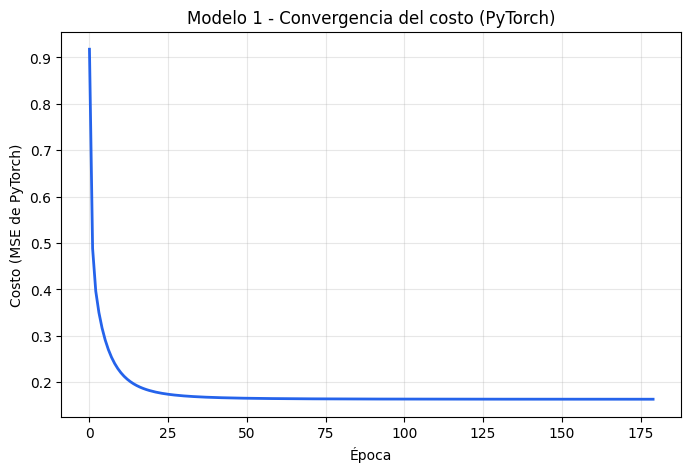

In [12]:
plt.figure(figsize=(8,5))
plt.plot(historial1, lw=2, color='#2563eb')
plt.xlabel('Época')
plt.ylabel('Costo (MSE de PyTorch)')
plt.title('Modelo 1 - Convergencia del costo (PyTorch)')
plt.grid(alpha=0.3)
plt.show()

### 4.2 Evaluación del Modelo 1 en el conjunto de prueba

In [13]:
modelo1.eval()
with torch.no_grad():
    y_pred1_norm = modelo1(X_test_t).numpy().flatten()
y_pred1 = y_pred1_norm * y_sigma + y_mu

mse1, rmse1, mae1, r2_1 = evaluar(y_test, y_pred1)
print('--- Modelo 1: Regresión Lineal Multivariable (PyTorch) ---')
print(f'MSE  = {mse1:,.2f}')
print(f'RMSE = {rmse1:,.2f}')
print(f'MAE  = {mae1:,.2f}')
print(f'R2   = {r2_1:.4f}')
print(f'Número de predicciones evaluadas: {m_test}')

--- Modelo 1: Regresión Lineal Multivariable (PyTorch) ---
MSE  = 1,293,464,246.81
RMSE = 35,964.76
MAE  = 21,959.75
R2   = 0.8387
Número de predicciones evaluadas: 586


## 5. Modelo 3: Ecuación de la Normal (con tensores de PyTorch)

Como se explicó al inicio del notebook, este modelo **no se entrena**: se calcula con una fórmula cerrada de álgebra lineal (`theta = (Xᵀ X)⁻¹ Xᵀ y`), usando `torch.linalg.pinv` (pseudo-inversa, más estable que la inversa exacta cuando hay columnas correlacionadas) en lugar de un ciclo de entrenamiento con `Dataset`/`DataLoader`/optimizador.

In [14]:
unos_train = torch.ones((X_train_t.shape[0], 1))
unos_test = torch.ones((X_test_t.shape[0], 1))
X_train_b = torch.cat([unos_train, X_train_t], dim=1)
X_test_b = torch.cat([unos_test, X_test_t], dim=1)

theta_ne = torch.linalg.pinv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train_t

print('Theta calculado por la Ecuación de la Normal (primeros 5 valores):')
print(theta_ne[:5].flatten())

Theta calculado por la Ecuación de la Normal (primeros 5 valores):
tensor([-8.7544e-08, -9.6779e-02, -1.6260e-02,  5.2470e-02,  3.1630e-01])


### 5.1 Gráfico de costo - Modelo 3

A diferencia del descenso de gradiente, la Ecuación de la Normal no tiene una curva de convergencia por iteraciones, porque no itera: llega a la solución óptima en un solo paso. Para dar el "gráfico de costo" que pide el enunciado en este caso, se compara ese costo (una línea horizontal, constante) contra la curva de convergencia del Modelo 1, mostrando que el descenso de gradiente efectivamente converge hacia el mismo valor que calcula la Ecuación de la Normal de forma directa.

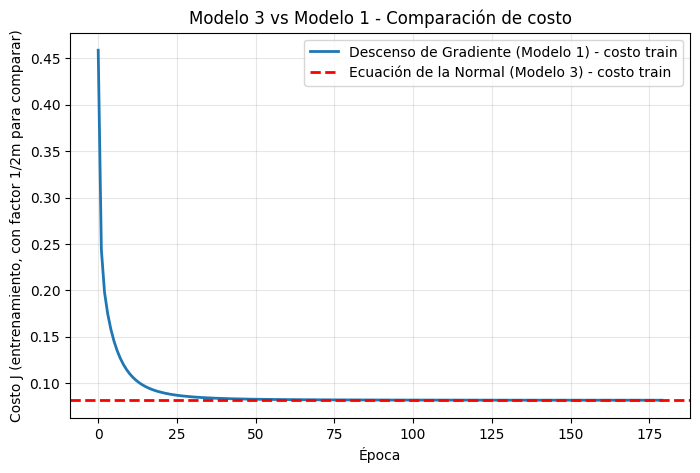

In [15]:
def costo_mse_medio(X, y, theta):
    m_ = y.shape[0]
    pred = X @ theta
    return ((1/(2*m_)) * torch.sum((pred - y)**2)).item()

costo_ne_train = costo_mse_medio(X_train_b, y_train_t, theta_ne)

plt.figure(figsize=(8,5))
plt.plot([h/2 for h in historial1], lw=2, label='Descenso de Gradiente (Modelo 1) - costo train')
plt.axhline(y=costo_ne_train, color='red', linestyle='--', lw=2, label='Ecuación de la Normal (Modelo 3) - costo train')
plt.xlabel('Época')
plt.ylabel('Costo J (entrenamiento, con factor 1/2m para comparar)')
plt.title('Modelo 3 vs Modelo 1 - Comparación de costo')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5.2 Evaluación del Modelo 3 en el conjunto de prueba

In [16]:
with torch.no_grad():
    y_pred_ne_norm = (X_test_b @ theta_ne).numpy().flatten()
y_pred_ne = y_pred_ne_norm * y_sigma + y_mu

mse_ne, rmse_ne, mae_ne, r2_ne = evaluar(y_test, y_pred_ne)
print('--- Modelo 3: Ecuación de la Normal (PyTorch) ---')
print(f'MSE  = {mse_ne:,.2f}')
print(f'RMSE = {rmse_ne:,.2f}')
print(f'MAE  = {mae_ne:,.2f}')
print(f'R2   = {r2_ne:.4f}')

--- Modelo 3: Ecuación de la Normal (PyTorch) ---
MSE  = 1,297,747,203.14
RMSE = 36,024.26
MAE  = 21,958.50
R2   = 0.8381


## 6. Modelo 2: Regresión Polinómica (PyTorch)

Igual que en el Laboratorio 3 original, se agrega el cuadrado de las 6 propiedades más correlacionadas con `SalePrice` (`Overall Qual`, `Gr Liv Area`, `Garage Cars`, `Garage Area`, `Total Bsmt SF`, `1st Flr SF`), en lugar de elevar al cuadrado las 36 propiedades completas, para evitar una explosión de columnas poco útiles. Esto lleva el modelo de 36 a 42 propiedades de entrada.

In [17]:
top_feats = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF']
idxs = [feature_names.index(f) for f in top_feats]

def agregar_terminos_cuadraticos(X, idxs):
    extra = [X[:, i] ** 2 for i in idxs]
    return np.concatenate([X, np.array(extra).T], axis=1)

X_train_poly = agregar_terminos_cuadraticos(X_train, idxs)
X_test_poly = agregar_terminos_cuadraticos(X_test, idxs)

print('n original:', X_train.shape[1])
print('n con términos polinómicos:', X_train_poly.shape[1])

n original: 36
n con términos polinómicos: 42


In [18]:
X_train_poly_norm, mu_p, sigma_p = normalizar(X_train_poly)
X_test_poly_norm, _, _ = normalizar(X_test_poly, mu_p, sigma_p)

X_train_poly_t = torch.tensor(X_train_poly_norm, dtype=torch.float32)
y_train_poly_t = torch.tensor(y_train_norm, dtype=torch.float32).view(-1, 1)
X_test_poly_t = torch.tensor(X_test_poly_norm, dtype=torch.float32)

dataset2 = DatasetViviendas(X_train_poly_t, y_train_poly_t)
dataloader2 = torch.utils.data.DataLoader(dataset2, batch_size=len(dataset2), shuffle=False)

modelo2 = torch.nn.Linear(X_train_poly.shape[1], 1)
optimizer2 = torch.optim.SGD(modelo2.parameters(), lr=0.05)

In [19]:
historial2 = []

for epoca in range(max_epocas):
    for x_lote, y_lote in dataloader2:
        optimizer2.zero_grad()
        y_pred = modelo2(x_lote)
        loss = criterion(y_pred, y_lote)
        loss.backward()
        optimizer2.step()
    historial2.append(loss.item())
    if epoca > 0 and abs(historial2[-2] - historial2[-1]) < 1e-6:
        print(f'Convergencia alcanzada en la época {epoca}')
        break

print(f'Costo inicial (dividido entre 2): {historial2[0]/2:.4f}')
print(f'Costo final   (dividido entre 2): {historial2[-1]/2:.5f}')

Convergencia alcanzada en la época 1834
Costo inicial (dividido entre 2): 0.6963
Costo final   (dividido entre 2): 0.05640


### 6.1 Gráfico de costo - Modelo 2

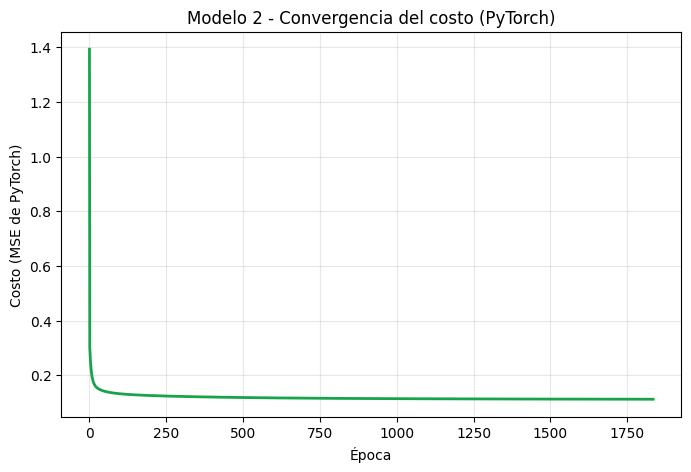

In [20]:
plt.figure(figsize=(8,5))
plt.plot(historial2, lw=2, color='#16a34a')
plt.xlabel('Época')
plt.ylabel('Costo (MSE de PyTorch)')
plt.title('Modelo 2 - Convergencia del costo (PyTorch)')
plt.grid(alpha=0.3)
plt.show()

### 6.2 Evaluación del Modelo 2 en el conjunto de prueba

In [21]:
modelo2.eval()
with torch.no_grad():
    y_pred2_norm = modelo2(X_test_poly_t).numpy().flatten()
y_pred2 = y_pred2_norm * y_sigma + y_mu

mse2, rmse2, mae2, r2_2 = evaluar(y_test, y_pred2)
print('--- Modelo 2: Regresión Polinómica (PyTorch) ---')
print(f'MSE  = {mse2:,.2f}')
print(f'RMSE = {rmse2:,.2f}')
print(f'MAE  = {mae2:,.2f}')
print(f'R2   = {r2_2:.4f}')

--- Modelo 2: Regresión Polinómica (PyTorch) ---
MSE  = 1,123,251,826.98
RMSE = 33,514.95
MAE  = 19,574.78
R2   = 0.8599


## 7. Comparación final de los tres modelos y con el Laboratorio 3

In [22]:
comparacion = pd.DataFrame({
    'Modelo': [
        '1. Lineal Multivariable (NumPy, Lab3 original)',
        '1. Lineal Multivariable (PyTorch, Lab6)',
        '2. Polinómica (NumPy, Lab3 original)',
        '2. Polinómica (PyTorch, Lab6)',
        '3. Ecuación de la Normal (NumPy, Lab3 original)',
        '3. Ecuación de la Normal (PyTorch, Lab6)',
    ],
    'MSE': [1297747145.62, mse1, 1109424446.37, mse2, 1297747145.62, mse_ne],
    'RMSE': [36024.26, rmse1, 33308.02, rmse2, 36024.26, rmse_ne],
    'MAE': [21958.50, mae1, 19491.29, mae2, 21958.50, mae_ne],
    'R2': [0.8381, r2_1, 0.8616, r2_2, 0.8381, r2_ne],
})
comparacion

,Modelo,MSE,RMSE,MAE,R2
0,"1. Lineal Multivariable (NumPy, Lab3 original)",1.297747e+09,36024.260000,21958.500000,0.838100
1,"1. Lineal Multivariable (PyTorch, Lab6)",1.293464e+09,35964.763962,21959.746193,0.838671
2,"2. Polinómica (NumPy, Lab3 original)",1.109424e+09,33308.020000,19491.290000,0.861600
3,"2. Polinómica (PyTorch, Lab6)",1.123252e+09,33514.949306,19574.778906,0.859901
4,"3. Ecuación de la Normal (NumPy, Lab3 original)",1.297747e+09,36024.260000,21958.500000,0.838100
5,"3. Ecuación de la Normal (PyTorch, Lab6)",1.297747e+09,36024.258537,21958.500516,0.838137


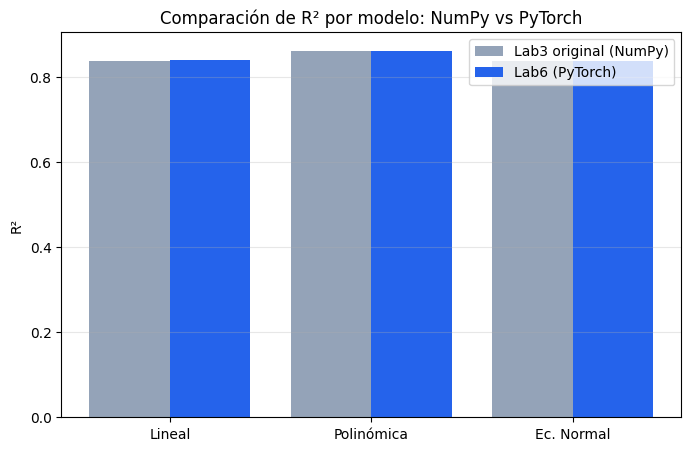

In [23]:
plt.figure(figsize=(8,5))
modelos_nombres = ['Lineal', 'Polinómica', 'Ec. Normal']
r2_pytorch = [r2_1, r2_2, r2_ne]
r2_original = [0.8381, 0.8616, 0.8381]
x_pos = np.arange(len(modelos_nombres))
plt.bar(x_pos - 0.2, r2_original, width=0.4, label='Lab3 original (NumPy)', color='#94a3b8')
plt.bar(x_pos + 0.2, r2_pytorch, width=0.4, label='Lab6 (PyTorch)', color='#2563eb')
plt.xticks(x_pos, modelos_nombres)
plt.ylabel('R²')
plt.title('Comparación de R² por modelo: NumPy vs PyTorch')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 8. Guardado de los modelos entrenados

Se guardan por separado los pesos del Modelo 1 y del Modelo 2 (ambos son objetos `torch.nn.Linear`). El Modelo 3 no se guarda de esta forma porque no es un `nn.Module`, sino un tensor `theta_ne` calculado directamente; se guarda con `torch.save` de todas formas, ya que sigue siendo un tensor de PyTorch.

In [24]:
torch.save(modelo1.state_dict(), 'lab3_modelo1_lineal.pt')
torch.save(modelo2.state_dict(), 'lab3_modelo2_polinomico.pt')
torch.save(theta_ne, 'lab3_modelo3_ecuacion_normal.pt')
print('Los tres modelos fueron guardados correctamente.')

Los tres modelos fueron guardados correctamente.


## 9. Conclusiones

- Los tres modelos reconstruidos con PyTorch llegaron a métricas prácticamente idénticas a las del Laboratorio 3 original: el Modelo 1 (lineal) obtuvo R²≈0.838 en ambos casos, y el Modelo 2 (polinómico) siguió siendo el mejor de los tres, confirmando que agregar los términos cuadráticos de las propiedades más correlacionadas sí capturó una relación no lineal real en los datos, no fue una casualidad de la implementación en NumPy.
- El Modelo 3 (Ecuación de la Normal) volvió a demostrar ser matemáticamente equivalente al Modelo 1: mismo resultado final, pero calculado en un solo paso de álgebra lineal en lugar de miles de iteraciones. Esto se mantiene sin importar si el cálculo se hace con NumPy o con tensores de PyTorch, porque es la misma operación matemática.
- Se reutilizaron las dos correcciones aprendidas al reconstruir el Laboratorio 2 (tasa de aprendizaje ajustada por el factor 1/2 de `MSELoss`, y criterio de parada por convergencia en lugar de iteraciones fijas), lo que confirma que esas no fueron soluciones específicas de un solo caso, sino ajustes generales necesarios cada vez que se traduce un modelo de descenso de gradiente manual a PyTorch.
- La principal diferencia conceptual de este laboratorio frente a los anteriores fue reconocer que **no todos los "modelos" de un laboratorio de Machine Learning encajan en el patrón de entrenamiento con `Dataset`/`DataLoader`/optimizador** de PyTorch: la Ecuación de la Normal es igual de válida y útil, pero es una herramienta de álgebra lineal, no un modelo entrenable por gradientes.